# Groups and the GDL Blueprint

## Overview ##


This project investigates matrix groups and their fundamental properties, with particular emphasis on the Special Linear Group (SL(n)) and the Orthogonal Group (O(n)). The study focuses on how core group axioms—closure, associativity, identity, and invertibility—are satisfied within matrix operations.

In addition, the project explores how these algebraic structures relate to linear transformations and their significance in modern applications such as deep learning. By examining symmetry and structure in matrix groups, the project highlights their role in building more robust and mathematically grounded machine learning models.Overview

This project investigates matrix groups and their fundamental properties, with particular emphasis on the Special Linear Group (SL(n)) and the Orthogonal Group (O(n)). The study focuses on how core group axioms—closure, associativity, identity, and invertibility—are satisfied within matrix operations.

In addition, the project explores how these algebraic structures relate to linear transformations and their significance in modern applications such as deep learning. By examining symmetry and structure in matrix groups, the project highlights their role in building more robust and mathematically grounded machine learning models.

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.fftpack import diff as psdiff
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR
import itertools

import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

##  Matrix Groups

### 📌 Problem

This section verifies the group axioms for important matrix groups, namely the Special Linear Group (SL(d)) and the Orthogonal Group (O(d)).

Associativity follows directly from the properties of matrix multiplication.



### 🔷 Special Linear Group

Show thath $SL(d)=\{A \in \mathbb{R}^{d \times d} | \text{det}(A)=1\}$, with the operation being matrix multiplication, is a group.

### ✅ Verification of Group Axioms

 We consider the set $SL(d)=\{A \in \mathbb{R}^{d \times d} \mid \det(A)=1\}$ and verify that it forms a group under matrix multiplication.

1. **Closure**:  
If $A,B \in SL(d)$, then $\det(A)=1$ and $\det(B)=1$.  
Since $\det(AB)=\det(A)\det(B)=1 \cdot 1=1$, we have $AB \in SL(d)$.

2. **Associativity**:  
Matrix multiplication is associative for all matrices.

3. **Identity element**:  
The identity matrix $I$ satisfies $\det(I)=1$, so $I \in SL(d)$.

4. **Inverse element**:  
If $A \in SL(d)$, then $\det(A)=1$.  
The inverse $A^{-1}$ exists and satisfies $\det(A^{-1})=\frac{1}{\det(A)}=1$,  
so $A^{-1} \in SL(d)$.

Thus, all group axioms are satisfied, and $SL(d)$ forms a group under matrix multiplication.

### 🔷 Orthogonal Group

### 📌 Problem

We consider the set $O(d) = \{ A \in \mathbb{R}^{d \times d} \mid \langle Ax, Ay \rangle = \langle x, y \rangle \ \forall x,y \in \mathbb{R}^d \}$ and verify that it forms a group under matrix multiplication.

### ✅ Verification of Group Axioms

To show that $O(d)=\{A \in \mathbb{R}^{d \times d} : \langle Ax, Ay \rangle = \langle x, y \rangle \ \forall x,y \in \mathbb{R}^d\}$ is a group under matrix multiplication, we verify the group axioms:

### 1. Closure

Let $A, B \in O(d)$. Then for all $x, y$:

$\langle Ax, Ay \rangle = \langle x, y \rangle$,  
$\langle Bx, By \rangle = \langle x, y \rangle$

Then:

$\langle ABx, ABy \rangle = \langle Bx, By \rangle = \langle x, y \rangle$

Thus, $AB \in O(d)$.





### 2. Associativity

Matrix multiplication is associative for all matrices:

$(AB)C = A(BC)$





### 3. Identity element

The identity matrix $I$ satisfies:

$\langle Ix, Iy \rangle = \langle x, y \rangle$

Thus, $I \in O(d)$.





### 4. Inverse element

Let $A \in O(d)$. Then:

$\langle Ax, Ay \rangle = \langle x, y \rangle$

This implies:

$A^T A = I \quad \Rightarrow \quad A^{-1} = A^T$

Then:

$\langle A^{-1}x, A^{-1}y \rangle = \langle x, y \rangle$

Thus, $A^{-1} \in O(d)$.




### Conclusion

Thus, all group axioms are satisfied, and $O(d)$ forms a group under matrix multiplication.

## Regular Representation

### 📌 Problem

We consider a group $G$ acting on a space $\Omega$, which induces transformations on signals defined over $\Omega$.
Let $\mathcal{X}(\Omega) = \{ f : \Omega \to \mathbb{C} \}$ be the space of signals, and define the mapping: $(\rho(g)x)(u) = x(g^{-1}u)$ for $g \in G$ and $u \in \Omega$.

### ✅ Solution

### 🔷 Linearity

Let $x, y \in \mathcal{X}(\Omega)$ and $\alpha, \beta \in \mathbb{C}$. Then:

$(\rho(g)(\alpha x + \beta y))(u) = (\alpha x + \beta y)(g^{-1}u)$  

$= \alpha x(g^{-1}u) + \beta y(g^{-1}u)$  

$= \alpha (\rho(g)x)(u) + \beta (\rho(g)y)(u)$  

Thus, $\rho(g)(\alpha x + \beta y) = \alpha \rho(g)x + \beta \rho(g)y$, so $\rho(g)$ is linear.



### 🔷 Homomorphism Property

Let $g_1, g_2 \in G$. For any $u \in \Omega$:

$(\rho(g_1 g_2)x)(u) = x((g_1 g_2)^{-1}u)$  

$= x(g_2^{-1} g_1^{-1}u)$  

$= (\rho(g_2)x)(g_1^{-1}u)$  

$= (\rho(g_1)(\rho(g_2)x))(u)$  

Thus, $\rho(g_1 g_2) = \rho(g_1)\rho(g_2)$.




Therefore, $\rho$ defines a linear representation of the group $G$.

## Group Averaging

### 📌 Problem

Group averaging is a technique used to aggregate a function’s output over all transformations of a finite group $G$. This operation captures the symmetry of the group by averaging over its entire orbit.

In mathematical terms, let $f : \mathcal{X} \to \mathbb{R}$ be a linear function that is invariant under the action of $G$, i.e.,

$$f(gx) = f(x) \quad \forall g \in G, \ x \in \mathcal{X}$$

The group averaging operator is defined as

$$S_G x = \frac{1}{|G|} \sum_{g \in G} g x$$

Show that:

$$f(S_G x) = f(x)$$


### 🔷 Using Linearity

We begin by applying the linearity of $f$:

$$
f(S_G x) = f\left(\frac{1}{|G|} \sum_{g \in G} g x \right)
$$

$$
= \frac{1}{|G|} \sum_{g \in G} f(gx)
$$


### 🔷 Using $G$-Invariance

Since $f$ is invariant under the action of $G$, we have

$$
f(gx) = f(x) \quad \forall g \in G
$$

Thus,

$$
\frac{1}{|G|} \sum_{g \in G} f(gx)
= \frac{1}{|G|} \sum_{g \in G} f(x)
$$

$$
= \frac{1}{|G|} \cdot |G| \cdot f(x)
= f(x)
$$

Thus, $f(S_G x) = f(x)$, so $f$ is invariant under group averaging.

## Nonlinear Equivariance



### 📌 Problem

Let $\mathcal{X}(\Omega)$ be a space of signals, and let  $f : \mathcal{X} \to \mathcal{X}$ be a linear, $G$-equivariant function with respect to a representation $\rho$.

Let $\sigma : \mathcal{X} \to \mathcal{X}$ be an element-wise nonlinearity defined by $$(\sigma x)(u) = \sigma(x(u))$$. Show that the composition $\sigma \circ f$ is also $G$-equivariant.

### ✅ Solution

We verify that the composition $\sigma \circ f$ is $G$-equivariant.

Consider:

$$
(\sigma \circ f)(\rho(g)x) = \sigma(f(\rho(g)x))
$$

Since $f$ is $G$-equivariant, we have:

$$
f(\rho(g)x) = \rho(g)f(x)
$$

Thus,

$$
(\sigma \circ f)(\rho(g)x) = \sigma(\rho(g)f(x))
$$

Because $\sigma$ is applied element-wise, it commutes with the group action:

$$
\sigma(\rho(g)f(x)) = \rho(g)\sigma(f(x))
$$

Therefore,

$$
(\sigma \circ f)(\rho(g)x) = \rho(g)(\sigma \circ f)(x)
$$

Thus, $\sigma \circ f$ is $G$-equivariant.

## Korteweg–de Vries (KdV) Equation



We consider the Korteweg–de Vries (KdV) equation:
$$u_t + u u_x + u_{xxx} = 0$$
where $u u_x$ is a nonlinear convection term and $u_{xxx}$ is a dispersive term.This equation admits several continuous symmetries, including:

- **Time translation**:
  $$g_1(\varepsilon)u = u(x, t - \varepsilon)$$

- **Space translation**:
  $$g_2(\varepsilon)u = u(x - \varepsilon, t)$$

- **Galilean transformation**:
  $$g_3(c)u = u(x - ct, t) + c$$

- **Scaling transformation**:
  $$g_4(\varepsilon)u = e^{-2\varepsilon} u(e^{-\varepsilon}x, e^{-3\varepsilon}t)$$

  These symmetries play an important role in understanding invariant solutions and designing symmetry-aware models.

### 🔷 KdV Invariance

### 📌 Problem

Show that the KdV equation

$$
u_t + u u_x + u_{xxx} = 0
$$

is invariant under the following transformations:

- **Space translation**:
  $$g_2(\varepsilon)u = u(x - \varepsilon, t)$$

- **Galilean transformation**:
  $$g_3(c)u = u(x - ct, t) + c$$



We verify that the KdV equation
$$
u_t + u u_x + u_{xxx} = 0
$$
is invariant under the given transformations.


### ➤ Space Translation

Define the transformed function
$$
\tilde{u}(x,t) = u(x - \varepsilon, t)
$$

Then,
$$
\tilde{u}_t = u_t(x - \varepsilon, t), \quad
\tilde{u}_x = u_x(x - \varepsilon, t), \quad
\tilde{u}_{xxx} = u_{xxx}(x - \varepsilon, t)
$$

Substituting into the KdV equation gives
$$
\tilde{u}_t + \tilde{u}\tilde{u}_x + \tilde{u}_{xxx}
= u_t + u u_x + u_{xxx} \text{ evaluated at } (x - \varepsilon, t)
= 0
$$

Thus, the equation is invariant under space translation.


### ➤ Galilean Transformation
Define
$$
\tilde{u}(x,t) = u(x - ct, t) + c
$$

Then,
$$
\tilde{u}_t = u_t(x - ct, t) - c u_x(x - ct, t), \quad
\tilde{u}_x = u_x(x - ct, t), \quad
\tilde{u}_{xxx} = u_{xxx}(x - ct, t)
$$

Substituting into the equation:
$$
\tilde{u}_t + \tilde{u}\tilde{u}_x + \tilde{u}_{xxx}
= (u_t - c u_x) + (u + c)u_x + u_{xxx}
$$

$$
= u_t - c u_x + u u_x + c u_x + u_{xxx}
= u_t + u u_x + u_{xxx}
= 0
$$

Thus, the equation is invariant under the Galilean transformation.


Therefore, the KdV equation is invariant under both transformations.

### 🔷 Trajectory Generation

We generate initial conditions using a truncated Fourier series with random coefficients:

$$
u_0(x) = \sum_{k=1}^{K} A_k \sin\left(2\pi \ell_k x / L + \phi_k \right)
$$

where $K$ is the number of modes and $L$ is the domain length.

The parameters are sampled independently as follows:

- Amplitudes: $A_k \sim \mathcal{U}(-0.5, 0.5)$  
- Phases: $\phi_k \sim \mathcal{U}(0, 2\pi)$  
- Wavenumbers: $\ell_k \sim \mathcal{U}\{1, 3\}$ (discrete)

Using these initial conditions, we simulate the KdV equation over a fixed time interval and visualize the resulting trajectory.

In [ ]:

def kdv_pseudospectral(t: float, u: np.ndarray, L: float) -> np.ndarray:
    """
    Computes spatial derivatives for the KdV equation, using a pseudospectral method, discretization in x.
    Args:
        t (float): time point
        u (np.ndarray): 1D input field
        L (float): length of the spatial domain
    Returns:
        np.ndarray: reconstructed pseudospectral time derivative
    """
    ux = psdiff(u, order=1, period=L)
    uxxx = psdiff(u, order=3, period=L)
    ut = -u*ux - uxxx
    return ut

def solve(t: np.ndarray, u0: np.ndarray, L: float, tol: float = 1e-8) -> np.ndarray:
    """Solves the KdV equation using a pseudospectral method and an ODE solver.
    Args:
        t (np.ndarray): 1D array of time points to evaluate the solution at
        u0 (np.ndarray): 1D array of initial conditions for the spatial field
        L (float): length of the spatial domain
        tol (float): tolerance for the ODE solver
    Returns:
        np.ndarray: solution array
    """
    sol = solve_ivp(fun=kdv_pseudospectral, 
                                t_span=[t[0], t[-1]], 
                                y0=u0, 
                                method='Radau',
                                t_eval=t, 
                                args=(L,), 
                                atol=tol, 
                                rtol=tol)
    return sol.y

def plot_single_solution(x: np.ndarray, t: np.ndarray, sol: np.ndarray):
    """
    Plots a spatiotemporal heatmap of the Korteweg-de Vries (KdV) equation solution.
    
    This function visualizes how the spatial signal u(x) evolves over time t by 
    creating a 2D color plot (heatmap) where the x-axis represents the spatial 
    domain and the y-axis represents the temporal domain.

    Args:
        x (np.ndarray): 1D array of spatial grid points of shape (N_space,).
        t (np.ndarray): 1D array of time points of shape (N_time,).
        sol (np.ndarray): 2D array containing the solution trajectory with 
            shape (N_space, N_time).
            
    Returns:
        None: Displays the generated matplotlib figure.
    """
    plt.figure(figsize=(8, 4))
    
    X, T = np.meshgrid(x, t)
    heatmap = plt.pcolormesh(X, T, sol.T, cmap='RdBu_r', shading='gouraud')
    
    plt.title('KdV Trajectory', fontsize=16)
    plt.xlabel('x', fontsize=14)
    plt.ylabel('t', fontsize=14)
    
    cbar = plt.colorbar(heatmap)
    cbar.set_label('u(x,t)', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()

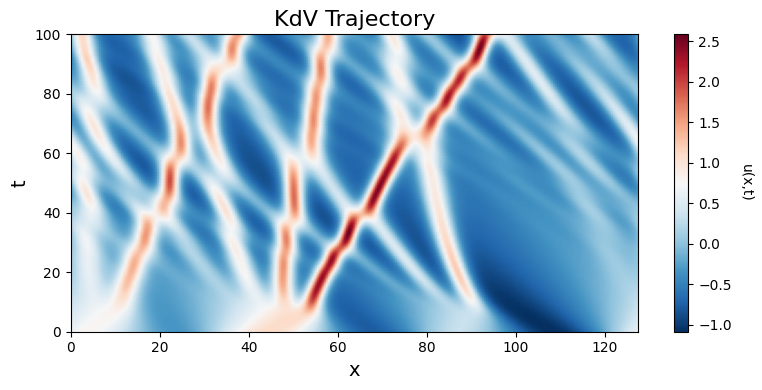

In [ ]:

def generate_initial_conditions(x: np.ndarray, K: int, L: float) -> np.ndarray:
    """Generates a random initial condition for the KdV equation as a sum of sine waves.
    Args:
        x (np.ndarray): 1D array of spatial grid points
        K (int): number of sine wave components to sum
        L (float): length of the spatial domain
    Returns:
        np.ndarray: 1D array of initial conditions for the spatial field
    """
  
    u0 = np.zeros_like(x)

    for _ in range(K):
        A_k = np.random.uniform(-0.5, 0.5)
        phi_k = np.random.uniform(0, 2*np.pi)
        l_k = np.random.randint(1, 4)  # {1,2,3}

        u0 += A_k * np.sin(2 * np.pi * l_k * x / L + phi_k)

    return u0


L = 128
N_space = 256

x = np.linspace(0, L, N_space, endpoint=False)

K = 10
u0 = generate_initial_conditions(x, K, L)

N_time = 200
t = np.linspace(0, 100, N_time)
sol = solve(t, u0, L)

plot_single_solution(x, t, sol)


### 🔷 Transformation Implementation

We implement the symmetry transformations corresponding to space translation and the Galilean boost, and apply them to the simulated trajectories.

To perform sub-pixel shifts efficiently, we use the Fourier shift theorem. A spatial shift can be computed in Fourier space as

$$
f(x - \varepsilon) = \mathcal{F}^{-1}\left( e^{-2\pi i \xi \varepsilon} \mathcal{F}(f(x)) \right)
$$

where $\xi$ denotes the frequencies in Fourier space and $\varepsilon$ is the shift parameter.

Using these transformations, we generate modified trajectories and verify numerically that they remain valid solutions of the KdV equation.

In [ ]:

def fourier_shift(u: np.ndarray, eps: float | np.ndarray = 0.0, dim: int = -1) -> np.ndarray:
    """Shifts a signal in the Fourier domain using the Shift Theorem.
    Args:
        u (np.ndarray): The input signal or trajectory to be shifted.
        eps (float | np.ndarray): The shift magnitude. Can be a scalar for a 
            global shift or an array for vectorized/batch shifts.
        dim (int): The axis along which to apply the shift. Defaults to -1 (space).
    Returns:
        np.ndarray: The shifted signal in the original physical domain.
    """
    n = u.shape[dim]
    u_hat = np.fft.rfft(u, axis=dim, norm='ortho')
  
    omega = np.arange(n // 2 + 1)
    if n % 2 == 0:
        omega[-1] = 0

    target_shape = [1] * u.ndim
    target_shape[dim] = -1
    omega = omega.reshape(target_shape)

    fs = np.exp(-2 * np.pi * 1j * omega * eps)   
    return np.fft.irfft(fs * u_hat, n=n, axis=dim, norm='ortho')


def plot_original_vs_transformed(
    x: np.ndarray, 
    t: np.ndarray, 
    original: np.ndarray, 
    space_translated: np.ndarray, 
    gallilean_boosted: np.ndarray
):
    """Visualizes the original KdV solution alongside its symmetry-transformed versions.
    Args:
        x (np.ndarray): 1D array of spatial grid points.
        t (np.ndarray): 1D array of time points.
        original (np.ndarray): The baseline KdV solution trajectory.
        space_translated (np.ndarray): The trajectory after applying g2(eps).
        gallilean_boosted (np.ndarray): The trajectory after applying g3(eps).
    Returns:
        None: Displays a 1x3 grid of spatiotemporal heatmaps.
    """

    all_data = [original, space_translated, gallilean_boosted]
    vmin = np.nanmin(all_data)
    vmax = np.nanmax(all_data)

    fig, axs = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
    

    X, T = np.meshgrid(x, t)

    plots = {
        "Original Solution": (axs[0], original),
        "Space Translated": (axs[1], space_translated),
        "Galilean Boosted": (axs[2], gallilean_boosted)
    }
    
    for title, (ax, data) in plots.items():

        heatmap = ax.pcolormesh(X, T, data.T, cmap="RdBu_r", shading="gouraud", vmin=vmin, vmax=vmax)
        
        ax.set_title(title, fontsize=15, fontweight="bold")
        ax.set_xlabel("Space (x)", fontsize=13)
        
        if ax == axs[0]:
            ax.set_ylabel("Time (t)", fontsize=13)
            
    cbar = fig.colorbar(heatmap, ax=axs.ravel().tolist(), fraction=0.02, pad=0.02)
    cbar.set_label("Amplitude", rotation=270, labelpad=15)
            
    plt.suptitle("Lie Point Symmetries of the KdV Equation", fontsize=18, y=1.05)
    plt.show()

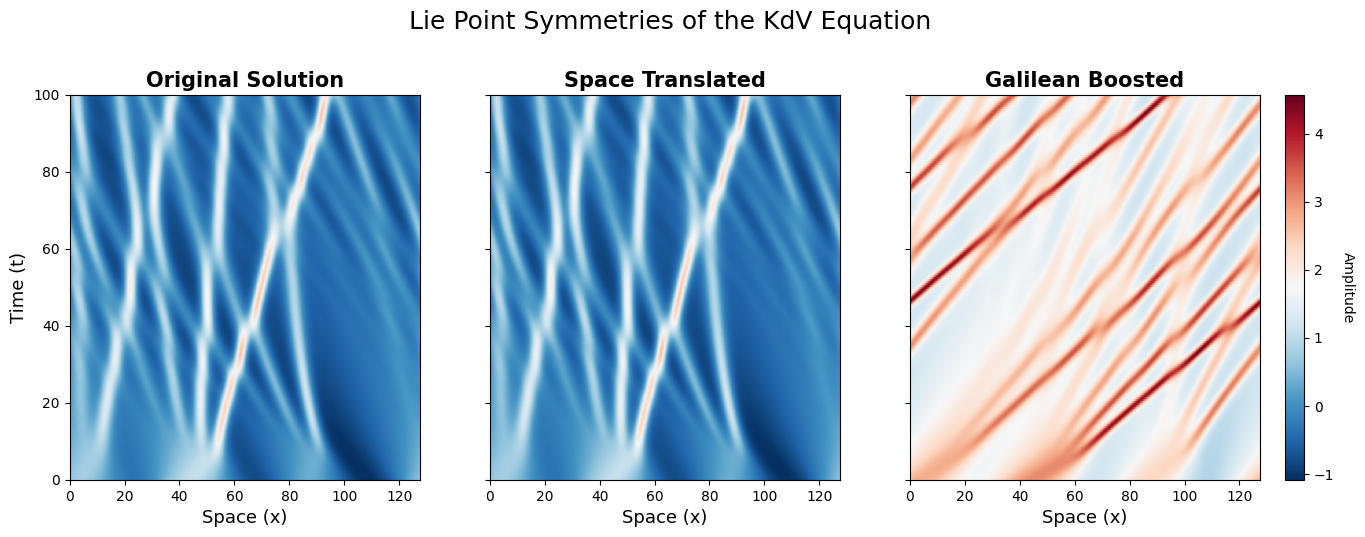

In [ ]:

def space_translation(u: np.ndarray, eps: float, L: float) -> np.ndarray:
    """Applies a space translation Lie point symmetry to a KdV solution u_new(x, t) = u(x - eps, t).
    Args:
        u (np.ndarray): 2D array of the spatiotemporal solution field (shape: N_space x N_time).
        eps (float): The translation parameter representing the shift distance.
        L (float): Length of the periodic spatial domain.   
    Returns:
        np.ndarray: 2D array of the transformed solution.
    """
    return fourier_shift(u, eps=eps, dim=0)



def gallilean_boost(t: np.ndarray, u: np.ndarray, eps: float, L: float) -> np.ndarray:
    """Applies the Galilean boost Lie point symmetry: g3(ε)u = u(x - εt, t) + ε.
    Args:
        t (np.ndarray): 1D array of time points of shape (N_time,).
        u (np.ndarray): 2D array of the spatiotemporal solution field 
            with shape (N_space, N_time).
        eps (float): The boost parameter representing the relative velocity.
        L (float): Total length of the periodic spatial domain.
    Returns:
        np.ndarray: 2D array of the boosted solution.
    """    

    u_boosted = np.zeros_like(u)

    for i, ti in enumerate(t):
        shift = eps * ti
        u_boosted[:, i] = fourier_shift(u[:, i], eps=shift, dim=0)

    return u_boosted + eps
   
eps = 2.0

u_space = space_translation(sol, eps, L)
u_boost = gallilean_boost(t, sol, eps, L)

plot_original_vs_transformed(x, t, sol, u_space, u_boost)


In [ ]:

def rel_l2_error_trajectory(traj1: np.ndarray, traj2: np.ndarray) -> float:
    """Computes the relative L2 error between two KdV trajectories.
    Args:
        traj1 (np.ndarray): First trajectory (shape: N_space x N_time).
        traj2 (np.ndarray): Second trajectory (shape: N_space x N_time).
    Returns:
        float: The relative L2 error computed as ||traj1 - traj2||_2 / ||traj1||_2.
    """
    numerator = np.linalg.norm(traj1 - traj2)
    denominator = np.linalg.norm(traj1)
    rel_error = numerator / denominator if denominator != 0 else np.inf
    return rel_error

In [ ]:

u0_space = fourier_shift(u0, eps=eps, dim=0)
sol_space_ref = solve(t, u0_space, L)

error_space = rel_l2_error_trajectory(sol_space_ref, u_space)
print("Space translation error:", error_space)


u0_boost = gallilean_boost(np.array([0.0]), u0[:, None], eps, L).squeeze()
sol_boost_ref = solve(t, u0_boost, L)

sol_transformed = gallilean_boost(t, sol, eps, L)

error_boost = rel_l2_error_trajectory(sol_boost_ref, sol_transformed)
print("Gallilean boost error:", error_boost)

Space translation error: 6.59042076467203e-13
Gallilean boost error: 0.3861455353219667


### 🔷 Neural Network Training



To evaluate the effect of symmetry-based data augmentation, we train a Fourier Neural Operator (FNO) model on the generated trajectories.

We compare the performance of two models on a validation set:

- **Baseline model**: trained on the original dataset without augmentation  
- **Augmented model**: trained on both original and symmetry-transformed trajectories (space translation and Galilean transformation)

This comparison allows us to assess the impact of incorporating symmetry into the training data.

In [ ]:

def trajectories_to_dataset(
    trajectories: list[np.ndarray],
    bundle_size: int = 4,
    stride: int = 1,
) -> TensorDataset:
    """Converts raw spatiotemporal trajectories into a supervised learning dataset.
    Args:
        trajectories (list[np.ndarray]): A list of 2D arrays, each with shape 
            (N_space, N_time), representing simulated KdV evolutions.
        bundle_size (int): The number of historical time steps used as input 
            features for the model. Defaults to 4.
        stride (int): The step size between sliding windows. Defaults to 1.
    Returns:
        TensorDataset: A dataset for model training.
    """
    X_list, y_list = [], []

    for u_tx in trajectories:
        u_tx = u_tx.T  
        n_time = u_tx.shape[0]
        for i in range(0, n_time - bundle_size, stride):
            history = u_tx[i:i + bundle_size]  
            target = u_tx[i + bundle_size]    
            X_list.append(history.T)         
            y_list.append(target)

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.stack(y_list, axis=0).astype(np.float32)

    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

We generate the datasets from simulated trajectories using the provided helper functions.

In [ ]:

K = 10
L = 128
N_grid_space = 256
T = 10
n_grid_time = 20
bundle_size = 4
stride = 1

n_train_base = 32
n_val = 16

x_train_grid = np.linspace(0.0, L * (1.0 - 1.0 / N_grid_space), N_grid_space)
t_train_grid = np.linspace(0.0, T, n_grid_time)

train_base_trajs = []
val_trajs = []
train_augmentations_only = []

for _ in range(n_train_base):
    u0 = generate_initial_conditions(x_train_grid, K, L)
    train_base_trajs.append(solve(t_train_grid, u0, L))

for _ in range(n_val):
    u0 = generate_initial_conditions(x_train_grid, K, L)
    val_trajs.append(solve(t_train_grid, u0, L))



eps_values = [1.0, -1.0]

for traj in train_base_trajs:
    for eps in eps_values:
        train_augmentations_only.append(space_translation(traj, eps, L))
        train_augmentations_only.append(gallilean_boost(t_train_grid, traj, eps, L))


train_augmented_trajs = train_base_trajs + train_augmentations_only
trainset = trajectories_to_dataset(
    train_base_trajs, bundle_size=bundle_size, stride=stride
)
trainset_aug = trajectories_to_dataset(
    train_augmented_trajs, bundle_size=bundle_size, stride=stride
)
valset = trajectories_to_dataset(
    val_trajs, bundle_size=bundle_size, stride=stride
)

print("Dataset sizes:")
print("  train (no aug):", len(trainset))
print("  train (aug):   ", len(trainset_aug))
print("  validation:    ", len(valset))

Dataset sizes:
  train (no aug): 512
  train (aug):    2560
  validation:     256


In [ ]:

def select_device() -> torch.device:
    """Prefer CUDA, then MPS, else CPU."""
    if torch.cuda.is_available():
        try:
            x = torch.randn(16, device="cuda")
            _ = torch.fft.rfft(x)
            return torch.device("cuda")
        except Exception as e:
            print(f"CUDA reported available but failed runtime check: {e}. Falling back.")

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        try:
            x = torch.randn(16, device="mps")
            _ = x.sum().item()
            return torch.device("mps")
        except Exception as e:
            print(f"MPS reported available but failed runtime check: {e}. Falling back.")

    return torch.device("cpu")


class SpectralConv1d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, modes: int):
        super().__init__()
        self.modes = modes
        scale = 1.0 / (in_channels * out_channels)
        self.weight = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes, dtype=torch.cfloat)
        )
        self.out_channels = out_channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        B, _, N = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)
        out_ft = torch.zeros(B, self.out_channels, x_ft.shape[-1], device=x.device, dtype=torch.cfloat)
        m = min(self.modes, x_ft.shape[-1])
        out_ft[:, :, :m] = torch.einsum("bcm,com->bom", x_ft[:, :, :m], self.weight[:, :, :m])
        return torch.fft.irfft(out_ft, n=N, dim=-1)


class SimpleFNO1d(nn.Module):
    def __init__(self, in_dim: int, width: int = 32, modes: int = 12, n_layers: int = 3):
        super().__init__()
        self.fc0 = nn.Linear(in_dim, width)
        self.sconvs = nn.ModuleList([SpectralConv1d(width, width, modes) for _ in range(n_layers)])
        self.ws = nn.ModuleList([nn.Conv1d(width, width, kernel_size=1) for _ in range(n_layers)])
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
    
        x = self.fc0(x)
        x = x.permute(0, 2, 1)
        for sc, w in zip(self.sconvs, self.ws):
            x = F.gelu(sc(x) + w(x))
        x = x.permute(0, 2, 1)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x).squeeze(-1)
        return x


def evaluate_mse(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    total = 0.0
    count = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = F.mse_loss(pred, yb, reduction="sum")
            total += loss.item()
            count += yb.shape[0]
    return total / count

The model is trained using a standard mean squared error (MSE) loss.

In [ ]:

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    total_steps: int = 2000,
    eval_every: int = 100,
    lr: float = 2e-3,
) -> tuple[np.ndarray, np.ndarray]:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-6)
    
    train_curve, val_curve = [], []
    train_iter = itertools.cycle(train_loader)
    
    model.train()
    running_loss = 0.0

    for step in range(1, total_steps + 1):
        xb, yb = next(train_iter)
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()

        pred = model(xb)
        loss = F.mse_loss(pred, yb)

        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        if step % eval_every == 0:
            avg_train_loss = running_loss / eval_every
            val_mse = evaluate_mse(model, val_loader, device)
            
            current_lr = optimizer.param_groups[0]['lr']
            
            train_curve.append(avg_train_loss)
            val_curve.append(val_mse)
            
            print(f"Step {step:04d}/{total_steps} | LR: {current_lr:.2e} | train MSE: {avg_train_loss:.4e} | val MSE: {val_mse:.4e}")
            
            running_loss = 0.0
            model.train()

    return np.array(train_curve), np.array(val_curve)

The implementation is designed to work with the chosen hyperparameters, while allowing flexibility for further experimentation.

Using device: cpu
Training model without augmentation...
Step 0050/1000 | LR: 1.99e-03 | train MSE: 7.3254e-02 | val MSE: 2.1765e+00
Step 0100/1000 | LR: 1.95e-03 | train MSE: 4.8298e-03 | val MSE: 5.9196e-01
Step 0150/1000 | LR: 1.89e-03 | train MSE: 1.6423e-03 | val MSE: 3.6132e-01
Step 0200/1000 | LR: 1.81e-03 | train MSE: 7.3169e-04 | val MSE: 2.4271e-01
Step 0250/1000 | LR: 1.71e-03 | train MSE: 4.1480e-04 | val MSE: 1.8134e-01
Step 0300/1000 | LR: 1.59e-03 | train MSE: 2.9116e-04 | val MSE: 1.7047e-01
Step 0350/1000 | LR: 1.45e-03 | train MSE: 2.3747e-04 | val MSE: 1.4212e-01
Step 0400/1000 | LR: 1.31e-03 | train MSE: 1.9460e-04 | val MSE: 1.1394e-01
Step 0450/1000 | LR: 1.16e-03 | train MSE: 1.6736e-04 | val MSE: 1.0033e-01
Step 0500/1000 | LR: 1.00e-03 | train MSE: 1.4498e-04 | val MSE: 9.5053e-02
Step 0550/1000 | LR: 8.44e-04 | train MSE: 1.3486e-04 | val MSE: 9.2093e-02
Step 0600/1000 | LR: 6.92e-04 | train MSE: 1.2157e-04 | val MSE: 8.8218e-02
Step 0650/1000 | LR: 5.47e-04 |

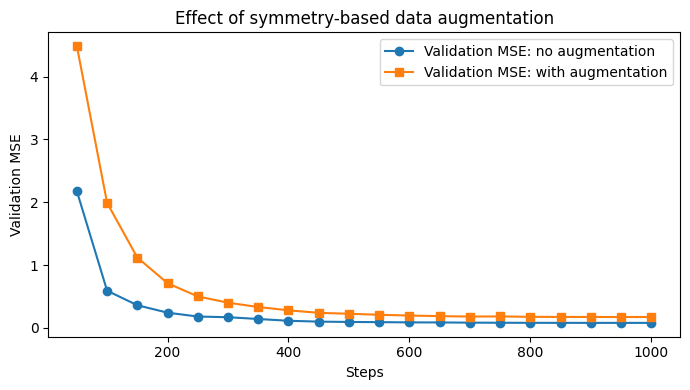

In [ ]:

batch_size = 64
train_base_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
train_aug_loader = DataLoader(trainset_aug, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)

device = select_device()
print(f"Using device: {device}")

in_dim = bundle_size
model_noaug = SimpleFNO1d(in_dim=in_dim, width=32, modes=12, n_layers=3).to(device)
model_aug = SimpleFNO1d(in_dim=in_dim, width=32, modes=12, n_layers=3).to(device)

total_steps = 1000
eval_every = 50
print("Training model without augmentation...")
train_noaug, val_noaug = train_model(model_noaug, train_base_loader, val_loader, device, total_steps=total_steps, eval_every=eval_every)
print("Training model with augmentation...")
train_aug, val_aug = train_model(model_aug, train_aug_loader, val_loader, device, total_steps=total_steps, eval_every=eval_every)
print("\nFinal validation MSE (no augmentation):", float(val_noaug[-1]))
print("Final validation MSE (with augmentation):", float(val_aug[-1]))
print("Relative improvement (%):", float((val_noaug[-1] - val_aug[-1]) / val_noaug[-1] * 100.0))

steps_axes = np.arange(eval_every, total_steps + 1, eval_every)
plt.figure(figsize=(7, 4))
plt.plot(steps_axes, val_noaug, "o-", label="Validation MSE: no augmentation")
plt.plot(steps_axes, val_aug, "s-", label="Validation MSE: with augmentation")
plt.xlabel("Steps")
plt.ylabel("Validation MSE")
plt.title("Effect of symmetry-based data augmentation")
plt.legend()
plt.tight_layout()
plt.show()